# Time Series Stock Forecast

# Libraries

In [1]:
!date

Tue Apr 14 15:42:09 CDT 2026


In [113]:
# load required modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import dates as mdates
from prophet import Prophet
# import fix_yahoo_finance as yf
import yfinance as yf
from pandas_datareader import data as pdr
import math
from sklearn.metrics import mean_absolute_error
from prophet.plot import plot_plotly, plot_components_plotly
# import plotly.graph_objs as go # this can be solved by installing '!pip install ipywidgets'

# Selecting a company with the start and end date of its stock prices.
## download dataset from Yahoo based on the user input (company, start date, end date)

In [114]:
stock = 'TSLA'
start = "2017-01-01"
end = "2023-12-08"
# df = pdr.get_data_yahoo(stock, start, end)
df = yf.download(stock, start, end)
dfa=df

[*********************100%***********************]  1 of 1 completed


In [115]:
df.shape

(1745, 5)

In [116]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2017-01-03,14.466000,14.688667,14.064000,14.324000,88849500
2017-01-04,15.132667,15.200000,14.287333,14.316667,168202500
2017-01-05,15.116667,15.165333,14.796667,15.094667,88675500
2017-01-06,15.267333,15.354000,15.030000,15.128667,82918500
2017-01-09,15.418667,15.461333,15.200000,15.264667,59692500


# Closing Price

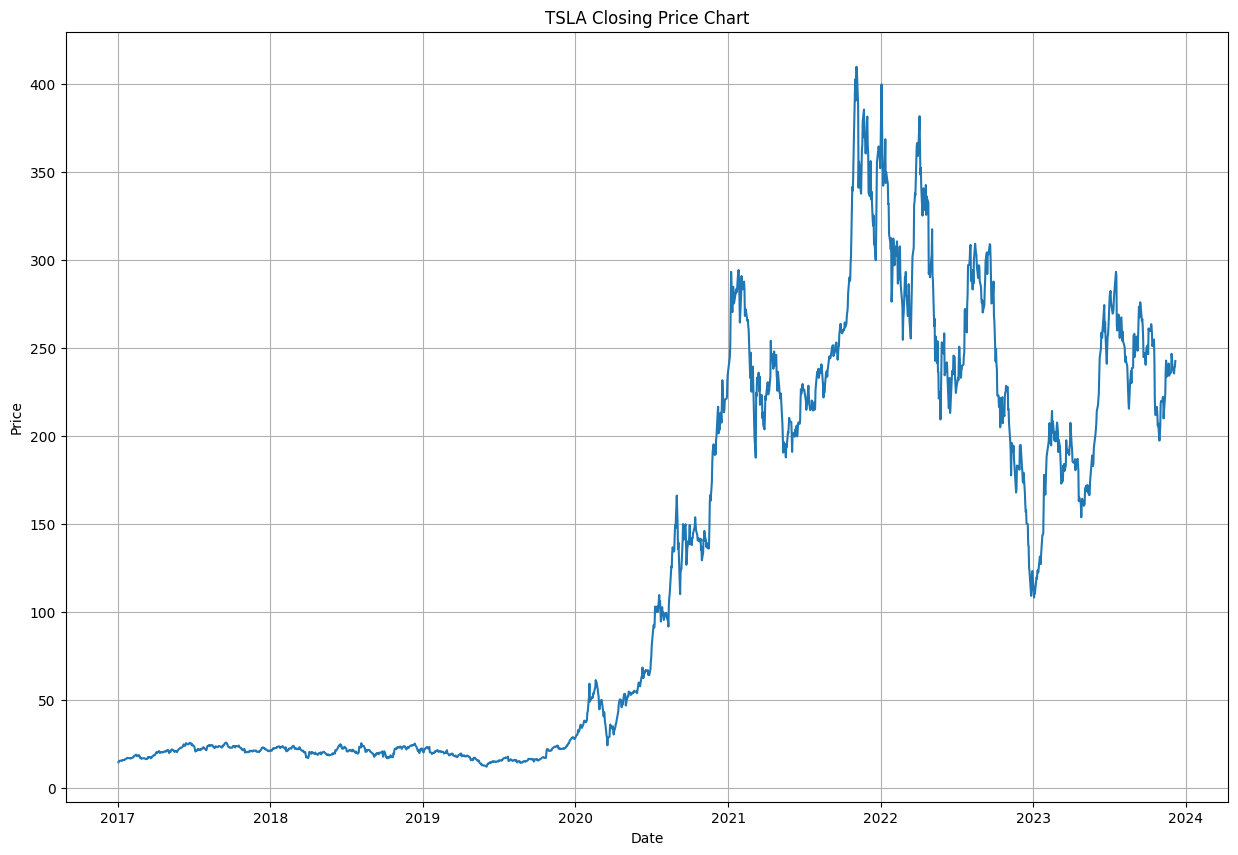

In [117]:
# df['Adj Close'].plot(figsize=(12,8))
# plt.show()

plt.figure(figsize=(15,10))
plt.plot(df['Close'])
plt.title(stock + ' Closing Price Chart')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()

In [118]:
print(df.columns)

MultiIndex([( 'Close', 'TSLA'),
            (  'High', 'TSLA'),
            (   'Low', 'TSLA'),
            (  'Open', 'TSLA'),
            ('Volume', 'TSLA')],
           names=['Price', 'Ticker'])


# High and Low prices 

In [119]:
#fig, ax = plt.subplots(figsize=(16, 4))
#(df.groupby(pd.Grouper(freq='W'))[['Low','High']]).mean().plot(color=['Red', 'Green'], ax=ax, title=stock+' High and Low Price ')

In [120]:
df.columns = df.columns.get_level_values(0)

In [121]:
df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2017-01-03,14.466000,14.688667,14.064000,14.324000,88849500
2017-01-04,15.132667,15.200000,14.287333,14.316667,168202500
2017-01-05,15.116667,15.165333,14.796667,15.094667,88675500
2017-01-06,15.267333,15.354000,15.030000,15.128667,82918500
2017-01-09,15.418667,15.461333,15.200000,15.264667,59692500


In [122]:
#fig, ax = plt.subplots(figsize=(16, 4))
#df.groupby(pd.Grouper(freq='W'))[['Low', 'High']].mean().plot(
    #ax=ax,
    #title=stock + ' High and Low Price'
#)

#plt.show()

# Weekly Stock Analysis Average

In [123]:
#weekly_avg = df.resample('W').mean()
#weekly_avg

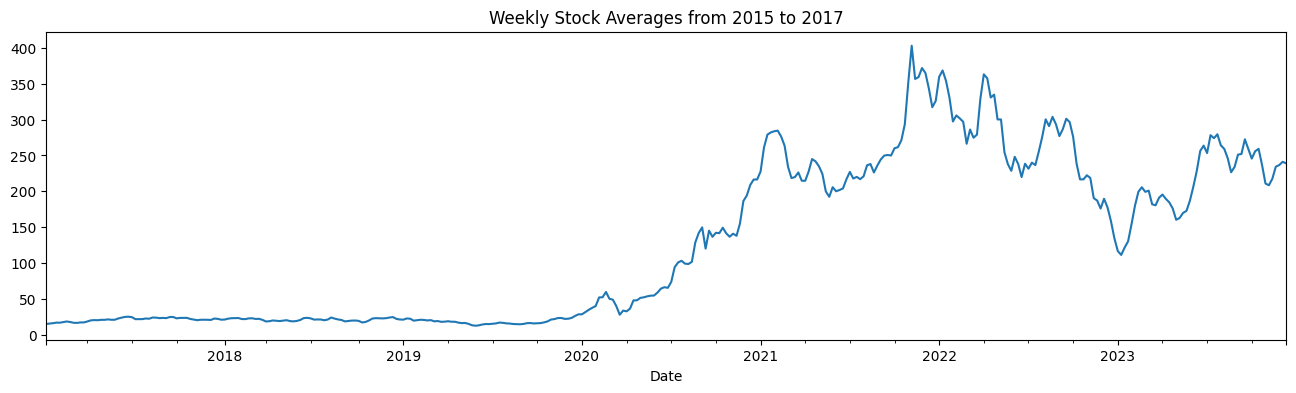

In [124]:
fig, ax = plt.subplots(figsize=(16, 4))

weekly_avg['Close'].plot(
    title='Weekly Stock Averages from 2015 to 2017',
    ax=ax
)

plt.show()

<Axes: title={'center': 'Weekly Stock Averages from 2015 to 2017'}, xlabel='Date'>

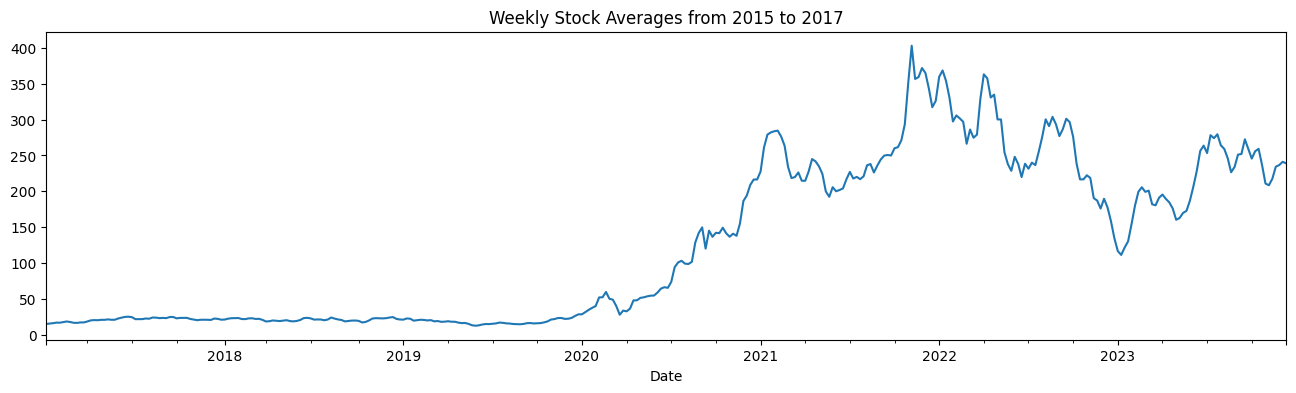

In [125]:
fig, ax = plt.subplots(figsize=(16, 4))
weekly_avg['Close'].plot(title='Weekly Stock Averages from 2015 to 2017', ax=ax)

# Monthly Returns
## Create new column 'Returns', 'Month_Name', Month_name_Year', and 'Month' 
## for compute closing price each month

In [126]:
monthly = df.asfreq('BM')
monthly['Returns'] = df['Close'].pct_change().dropna()

monthly['Month_Name'] = monthly.index.strftime("%b")
monthly['Month_Name_Year'] = monthly.index.strftime("%b-%Y")

monthly = monthly.reset_index()
monthly['Month'] = monthly["Date"].dt.month

/var/folders/g7/8fm0cc6d7p13pn53xrhdqw5c0000gn/T/ipykernel_33896/2901942917.py:1: FutureWarning: 'BM' is deprecated and will be removed in a future version, please use 'BME' instead.
  monthly = df.asfreq('BM')


In [127]:
monthly.head()

Price,Date,Close,High,Low,Open,Volume,Returns,Month_Name,Month_Name_Year,Month
0,2017-01-31,16.795334,17.059334,16.513332,16.615999,61741500.0,0.005187,Jan,Jan-2017,1
1,2017-02-28,16.666000,16.733334,16.260000,16.279333,91171500.0,0.015270,Feb,Feb-2017,2
2,2017-03-31,18.553333,18.645332,18.421333,18.582001,49419000.0,0.001367,Mar,Mar-2017,3
3,2017-04-28,20.938000,20.986668,20.533333,20.655333,67582500.0,0.017626,Apr,Apr-2017,4
4,2017-05-31,22.733999,22.859333,22.344000,22.512667,149451000.0,0.017636,May,May-2017,5


In [128]:

monthly['ReturnsPositive'] = 0 < monthly['Returns']
monthly['Date'] = pd.to_datetime(monthly['Date'])
monthly['Date'] = monthly['Date'].apply(mdates.date2num)

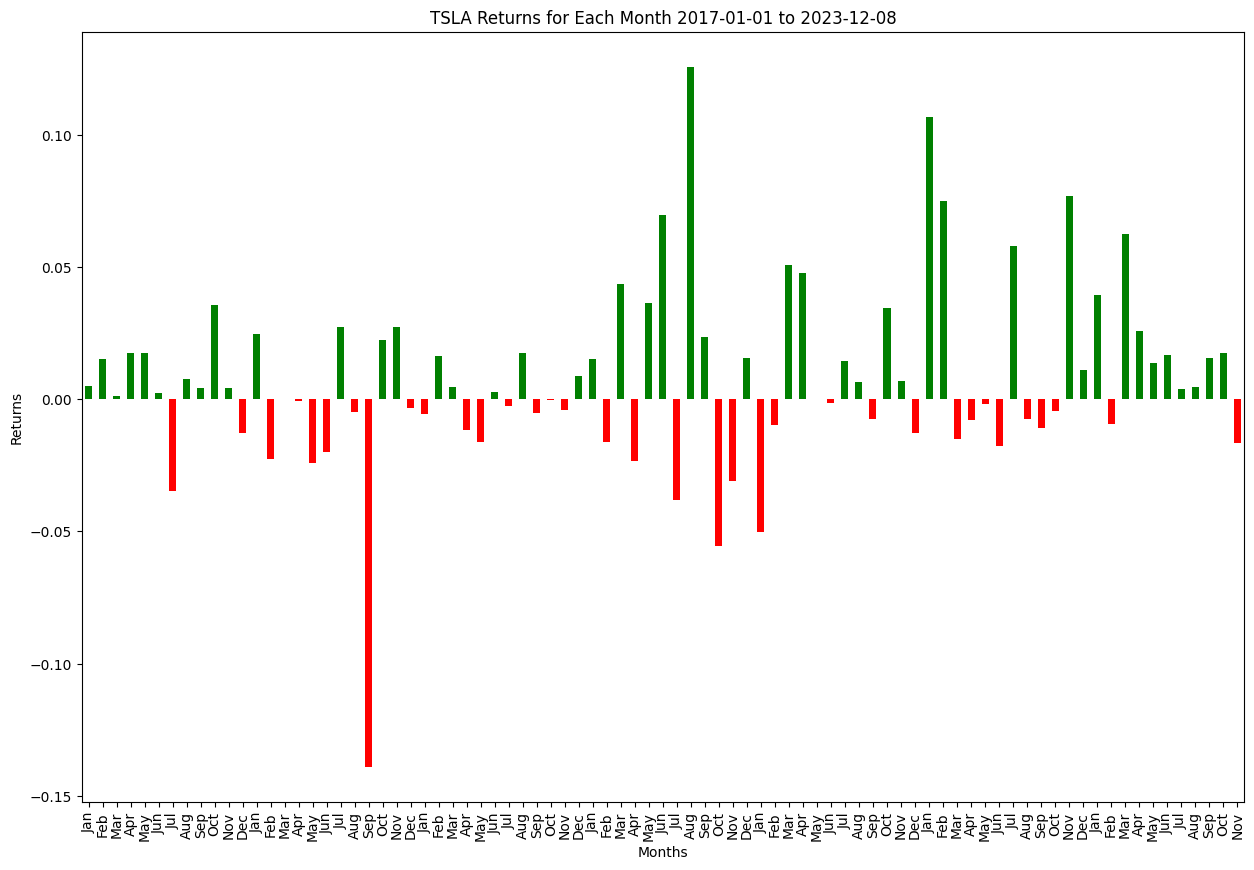

In [129]:
colors = monthly.ReturnsPositive.map({True: 'g', False: 'r'})
monthly['Returns'].plot(kind='bar', color = colors, figsize=(15,10))
plt.xlabel("Months")
plt.ylabel("Returns")
plt.title(stock + " Returns for Each Month " + str(start) + ' to ' + str(end))
plt.xticks(monthly.index, monthly['Month_Name'])
plt.show()

# Yearly returns

In [130]:
yearly = df.asfreq('BY')
yearly['Returns'] = df['Close'].pct_change().dropna()
yearly = yearly.reset_index()
yearly['Years'] = yearly['Date'].dt.year
print(yearly)

Price       Date       Close        High         Low        Open     Volume  \
0     2017-12-29   20.756666   21.094000   20.666668   21.078667   56658000   
1     2018-12-31   22.186666   22.614000   21.684000   22.519333   94534500   
2     2019-12-31   27.888666   28.086000   26.805332   27.000000  154285500   
3     2020-12-31  235.223328  239.573334  230.373337  233.330002  148949700   
4     2021-12-31  352.260010  360.666656  351.529999  357.813324   40733700   
5     2022-12-30  123.180000  124.480003  119.750000  119.949997  157777300   

Price   Returns  Years  
0     -0.012716   2017  
1     -0.003205   2018  
2      0.008753   2019  
3      0.015674   2020  
4     -0.012669   2021  
5      0.011164   2022  


/var/folders/g7/8fm0cc6d7p13pn53xrhdqw5c0000gn/T/ipykernel_33896/3878586787.py:1: FutureWarning: 'BY' is deprecated and will be removed in a future version, please use 'BYE' instead.
  yearly = df.asfreq('BY')


In [131]:
yearly['ReturnsPositive'] = 0 < yearly['Returns']
yearly['Date'] = pd.to_datetime(yearly['Date'])
yearly['Date'] = yearly['Date'].apply(mdates.date2num)

<Figure size 640x480 with 0 Axes>

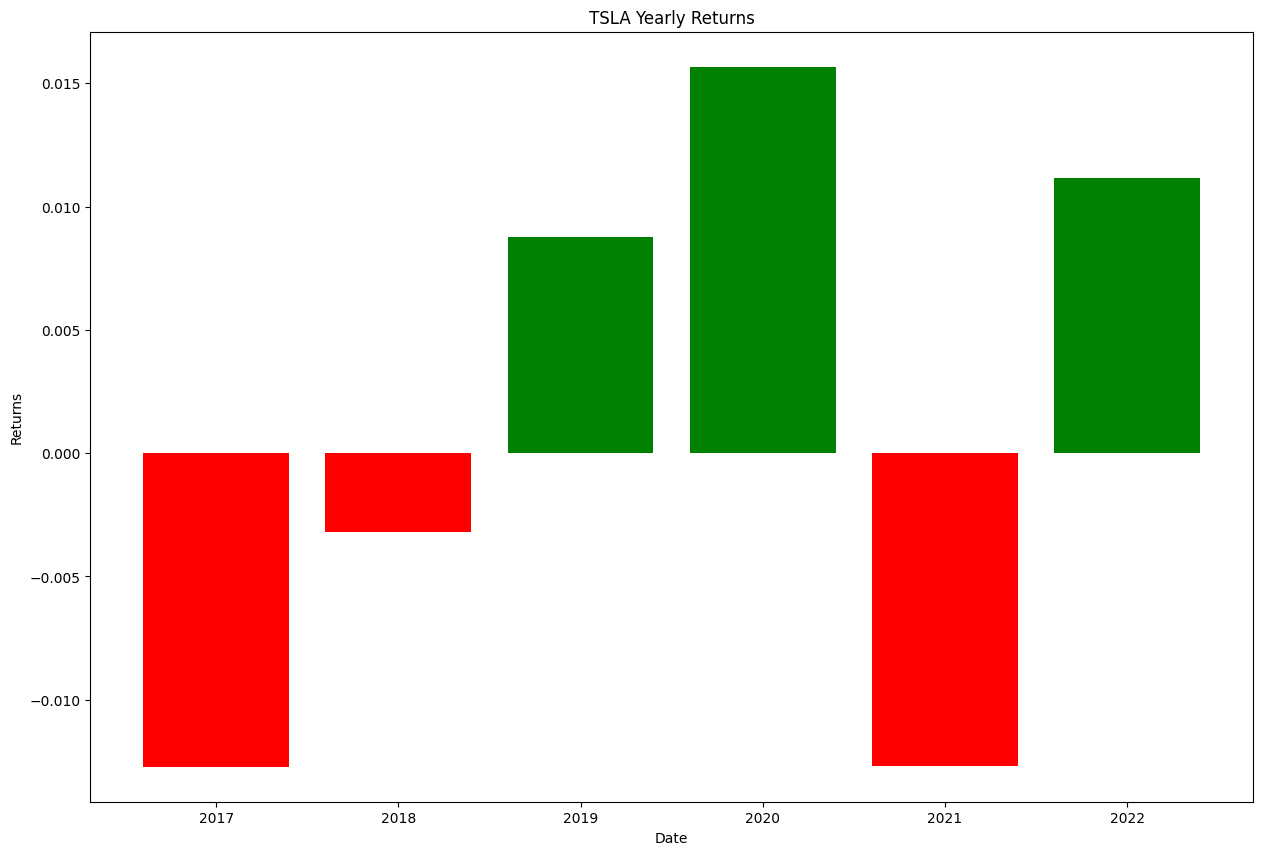

In [132]:
colors = yearly.ReturnsPositive.map({True: 'g', False: 'r'})
plt.gcf()
plt.gcf()
plt.figure(figsize=(15,10))
plt.bar(yearly['Years'], yearly['Returns'], color=colors, align='center')
plt.title(stock + ' Yearly Returns')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.show()

# Yearly Returns Avg

In [133]:
df['Returns'] = df['Close'].pct_change().dropna()
yearly_returns_avg = df['Returns'].groupby([df.index.year]).mean()
print(yearly_returns_avg)

Date
2017    0.001693
2018    0.000932
2019    0.001391
2020    0.010047
2021    0.002188
2022   -0.003293
2023    0.003486
Name: Returns, dtype: float64


In [134]:
df = df.reset_index().rename(columns={'Date':'ds', 'Adj Close':'y'})
#df['ds'] = pd.to_datetime(df.index)
#df['y'] = pd.DataFrame(df['Adj Close'])

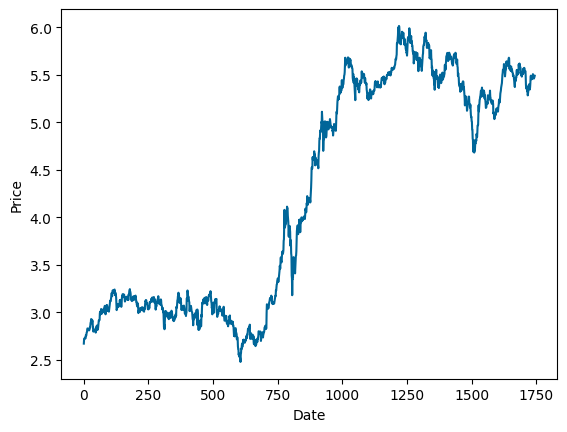

In [135]:
# Log Transform Data
#df['y'] = pd.DataFrame(np.log(df['y']))
df['y'] = np.log(df['Close'])

# plot data
ax = df['y'].plot(color='#006699');
ax.set_ylabel('Price');
ax.set_xlabel('Date');
plt.show()

# Data processings : creating training and testing data

In [136]:
# split data into train and test
df_train = df[:740]
df_test = df[740:]

In [137]:
df_train

Price,ds,Close,High,Low,Open,Volume,Returns,y
0,2017-01-03,14.466000,14.688667,14.064000,14.324000,88849500,NaN,2.671801
1,2017-01-04,15.132667,15.200000,14.287333,14.316667,168202500,0.046085,2.716856
2,2017-01-05,15.116667,15.165333,14.796667,15.094667,88675500,-0.001057,2.715798
3,2017-01-06,15.267333,15.354000,15.030000,15.128667,82918500,0.009967,2.725715
4,2017-01-09,15.418667,15.461333,15.200000,15.264667,59692500,0.009912,2.735579
...,...,...,...,...,...,...,...,...
735,2019-12-04,22.202000,22.524000,22.190001,22.516666,82995000,-0.009429,3.100182
736,2019-12-05,22.024668,22.294666,21.816668,22.188667,55869000,-0.007987,3.092163
737,2019-12-06,22.392668,22.590668,22.318001,22.333332,114186000,0.016709,3.108734
738,2019-12-09,22.635332,22.963333,22.338667,22.439333,135346500,0.010837,3.119512


In [138]:
df_test

Price,ds,Close,High,Low,Open,Volume,Returns,y
740,2019-12-11,23.513332,23.812668,23.406000,23.458668,103467000,0.011065,3.157568
741,2019-12-12,23.978666,24.182667,23.548668,23.661333,116458500,0.019790,3.177165
742,2019-12-13,23.892668,24.347334,23.642668,24.070000,98563500,-0.003586,3.173572
743,2019-12-16,25.433332,25.573999,24.166668,24.170000,272613000,0.064483,3.236061
744,2019-12-17,25.266001,25.700001,25.059999,25.266001,127452000,-0.006579,3.229460
...,...,...,...,...,...,...,...,...
1740,2023-12-01,238.830002,240.190002,231.899994,233.139999,121331700,-0.005207,5.475752
1741,2023-12-04,235.580002,239.369995,233.289993,235.750000,104099800,-0.013608,5.462051
1742,2023-12-05,238.720001,246.660004,233.699997,233.869995,137971100,0.013329,5.475291
1743,2023-12-06,239.369995,246.570007,239.169998,242.919998,126436200,0.002723,5.478010


# Model Fitting with train data

### Ref:
https://facebook.github.io/prophet/docs/uncertainty_intervals.html

#### Description
Make dataframe with future dates for forecasting. 

#### Usage
* make_future_dataframe(m, periods, freq = "day", include_history = TRUE)
#### Arguments
m : Prophet model object.
periods : Int number of periods to forecast forward.

freq : 'day', 'week', 'month', 'quarter', 'year', 1(1 sec), 60(1 minute) or 3600(1 hour).

include_history : Boolean to include the historical dates in the data frame for predictions.

In [139]:
# Model Fitting
# instantiate the Prophet class
mdl = Prophet(interval_width=0.95, daily_seasonality=True)
 
# fit the model on the training data
mdl.fit(df_train)
 
# define future time frame
future = mdl.make_future_dataframe(periods=24, freq='MS') # periods 24 months later ( in future )

16:21:02 - cmdstanpy - INFO - Chain [1] start processing
16:21:02 - cmdstanpy - INFO - Chain [1] done processing


In [140]:
# generate the forecast
forecast = mdl.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
759,2021-08-01,3.662812,0.247383,6.907423
760,2021-09-01,3.622936,0.041016,7.084059
761,2021-10-01,3.692690,-0.189327,7.474751
762,2021-11-01,3.902022,-0.243755,7.927403
763,2021-12-01,4.013681,-0.363028,8.246071


In [141]:
forecast['yhat_lower'].head()

0    2.551589
1    2.563238
2    2.577682
3    2.572278
4    2.606983
Name: yhat_lower, dtype: float64

In [142]:
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2017-01-03,2.637354,2.551589,2.779121,2.637354,2.637354,0.029910,0.029910,0.029910,-0.094171,...,-0.003092,-0.003092,-0.003092,0.127173,0.127173,0.127173,0.0,0.0,0.0,2.667264
1,2017-01-04,2.641595,2.563238,2.793217,2.641595,2.641595,0.033979,0.033979,0.033979,-0.094171,...,-0.002321,-0.002321,-0.002321,0.130471,0.130471,0.130471,0.0,0.0,0.0,2.675574
2,2017-01-05,2.645837,2.577682,2.805312,2.645837,2.645837,0.035658,0.035658,0.035658,-0.094171,...,-0.004300,-0.004300,-0.004300,0.134129,0.134129,0.134129,0.0,0.0,0.0,2.681495
3,2017-01-06,2.650078,2.572278,2.797580,2.650078,2.650078,0.036070,0.036070,0.036070,-0.094171,...,-0.007824,-0.007824,-0.007824,0.138065,0.138065,0.138065,0.0,0.0,0.0,2.686148
4,2017-01-09,2.662802,2.606983,2.824679,2.662802,2.662802,0.050436,0.050436,0.050436,-0.094171,...,-0.006005,-0.006005,-0.006005,0.150612,0.150612,0.150612,0.0,0.0,0.0,2.713238
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
759,2021-08-01,3.843421,0.247383,6.907423,0.474626,7.073890,-0.180610,-0.180610,-0.180610,-0.094171,...,0.011771,0.011771,0.011771,-0.098210,-0.098210,-0.098210,0.0,0.0,0.0,3.662812
760,2021-09-01,3.881140,0.041016,7.084059,0.243479,7.367746,-0.258204,-0.258204,-0.258204,-0.094171,...,-0.002321,-0.002321,-0.002321,-0.161712,-0.161712,-0.161712,0.0,0.0,0.0,3.622936
761,2021-10-01,3.917641,-0.189327,7.474751,0.026304,7.671429,-0.224951,-0.224951,-0.224951,-0.094171,...,-0.007824,-0.007824,-0.007824,-0.122956,-0.122956,-0.122956,0.0,0.0,0.0,3.692690
762,2021-11-01,3.955359,-0.243755,7.927403,-0.191521,7.959510,-0.053337,-0.053337,-0.053337,-0.094171,...,-0.006005,-0.006005,-0.006005,0.046839,0.046839,0.046839,0.0,0.0,0.0,3.902022


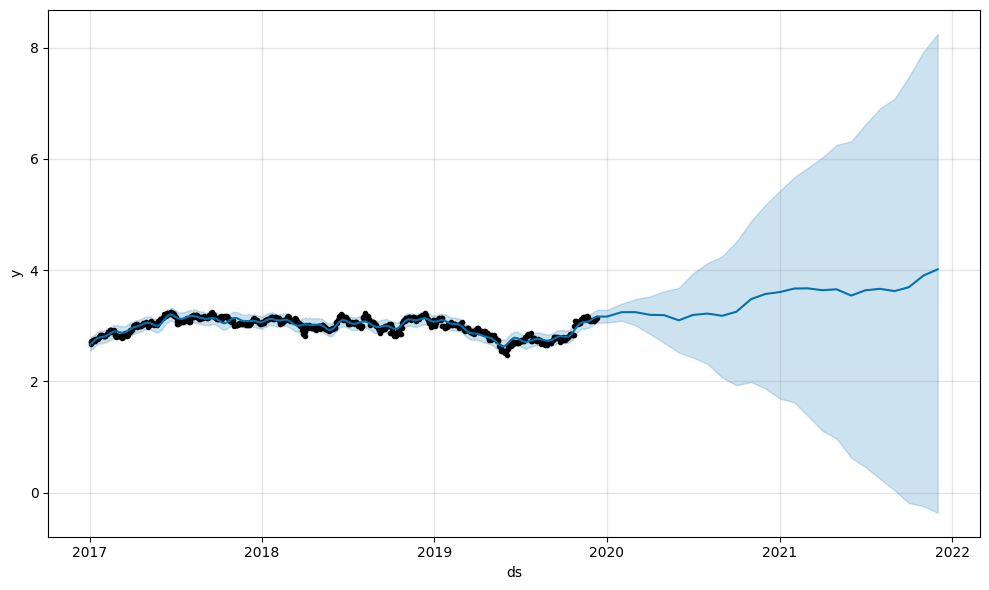

In [143]:
mdl.plot(forecast);
plt.show()

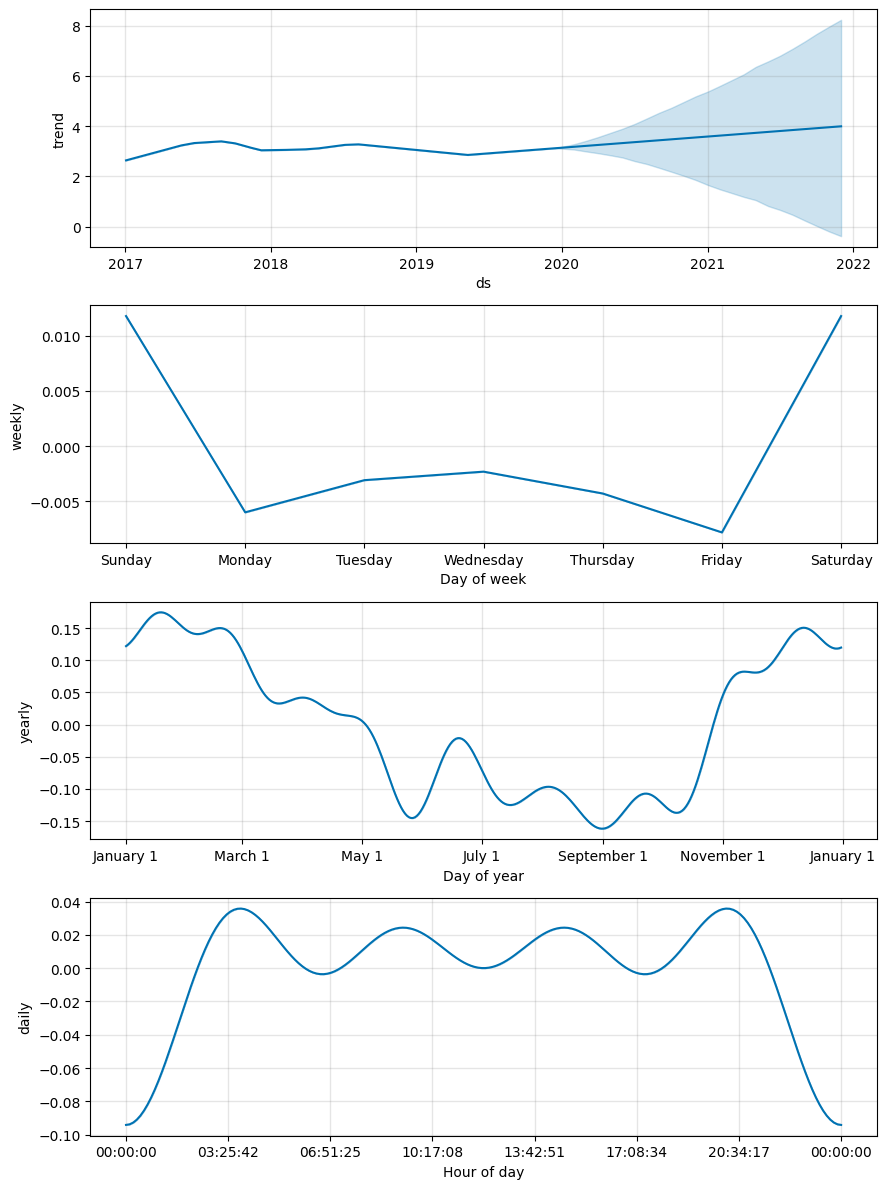

In [144]:
# plot time series components
mdl.plot_components(forecast)
plt.show()

In [145]:
# retransform using e
y_hat = np.exp(forecast['yhat'][:740])
y_true = np.exp(df['y'])
 
# compute the mean square error
mse = ((y_hat - y_true) ** 2).mean()
# mse = ((forecast['yhat'][:740] - df['y']) ** 2).mean()


print('Prediction quality: {:.2f} MSE ({:.2f} RMSE)'.format(mse, math.sqrt(mse)))

Prediction quality: 1.31 MSE (1.14 RMSE)


In [146]:
se = np.square(forecast.loc[:739, 'yhat'] - df['y'])
mse = np.mean(se)
rmse = np.sqrt(mse)
rmse

np.float64(0.05779008483138419)

In [147]:
#mae = mean_absolute_error(forecast.loc[:739, 'yhat'], df['y'])
#print('MAE: %.3f' % mae)

mae = mean_absolute_error(df.loc[:739, 'y'], forecast.loc[:739, 'yhat'])
print('MAE: %.3f' % mae)

MAE: 0.046


In [148]:
df['y']

0       2.671801
1       2.716856
2       2.715798
3       2.725715
4       2.735579
          ...   
1740    5.475752
1741    5.462051
1742    5.475291
1743    5.478010
1744    5.491579
Name: y, Length: 1745, dtype: float64

In [149]:
forecast['yhat'][:740]

0      2.667264
1      2.675574
2      2.681495
3      2.686148
4      2.713238
         ...   
735    3.139419
736    3.142892
737    3.144477
738    3.158823
739    3.164794
Name: yhat, Length: 740, dtype: float64

In [150]:
forecast.loc[:739, 'yhat']

0      2.667264
1      2.675574
2      2.681495
3      2.686148
4      2.713238
         ...   
735    3.139419
736    3.142892
737    3.144477
738    3.158823
739    3.164794
Name: yhat, Length: 740, dtype: float64

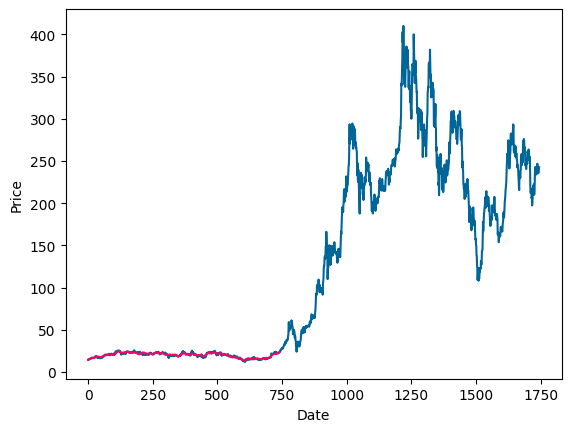

In [151]:
plt.plot(y_true, label='Original', color='#006699');
plt.plot(y_hat, color='#ff0066', label='Forecast');
plt.ylabel('Price');
plt.xlabel('Date');
plt.show()

In [152]:
import plotly.io as pio
pio.renderers.default = 'iframe'


In [153]:
plot_plotly(mdl, forecast)

In [70]:
!jupyter nbconvert --to webpdf "Forecasting using Time Series Analysis.ipynb"

[NbConvertApp] Converting notebook Forecasting using Time Series Analysis.ipynb to webpdf
[NbConvertApp] WARNING | Alternative text is missing on 11 image(s).
[NbConvertApp] Building PDF
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 715722 bytes to Forecasting using Time Series Analysis.pdf
